In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

%matplotlib inline

In [2]:
API_KEY = "aSFtZDqodejC7D_nJg9J0jVL1u7kqNVl"
url = f"https://api.massive.com/v2/aggs/ticker/AAPL/range/1/day/2025-01-02/2025-02-03?adjusted=true&sort=asc&apiKey={API_KEY}"

response = requests.get(url)
api_data = response.json()

print(api_data['results'][0])

{'v': 55740731.0, 'vw': 244.3303, 'o': 248.93, 'c': 243.85, 'h': 249.1, 'l': 241.8201, 't': 1735794000000, 'n': 685448}


In [3]:
apple_df = pd.DataFrame(api_data['results'])
apple_df.head()

,v,vw,o,c,h,l,t,n
0,55740731.0,244.3303,248.93,243.85,249.1000,241.8201,1735794000000,685448
1,40244114.0,243.0805,243.36,243.36,244.1800,241.8900,1735880400000,493786
2,45045571.0,245.1726,244.31,245.00,247.3300,243.2000,1736139600000,493920
3,40855960.0,242.9459,242.98,242.21,245.5500,241.3500,1736226000000,462887
4,37628940.0,242.2995,241.92,242.70,243.7123,240.0500,1736312400000,406916


In [4]:
apple_df['date'] = pd.to_datetime(apple_df['t'], origin='unix', unit='ms')
apple_df[['t', 'date']].head()

,t,date
0,1735794000000,2025-01-02 05:00:00
1,1735880400000,2025-01-03 05:00:00
2,1736139600000,2025-01-06 05:00:00
3,1736226000000,2025-01-07 05:00:00
4,1736312400000,2025-01-08 05:00:00


In [5]:
apple_df = apple_df.set_index('date')

In [6]:
mapping = {
    'o': 'open',
    'c': 'close',
    'h': 'high',
    'l': 'low',
    'n': 'number',
    'v': 'volume',
    'vw': 'avg_price'
}

apple_df = apple_df.rename(columns=mapping)
apple_df.head()

,volume,avg_price,open,close,high,low,t,number
date,,,,,,,,
2025-01-02 05:00:00,55740731.0,244.3303,248.93,243.85,249.1000,241.8201,1735794000000,685448
2025-01-03 05:00:00,40244114.0,243.0805,243.36,243.36,244.1800,241.8900,1735880400000,493786
2025-01-06 05:00:00,45045571.0,245.1726,244.31,245.00,247.3300,243.2000,1736139600000,493920
2025-01-07 05:00:00,40855960.0,242.9459,242.98,242.21,245.5500,241.3500,1736226000000,462887
2025-01-08 05:00:00,37628940.0,242.2995,241.92,242.70,243.7123,240.0500,1736312400000,406916


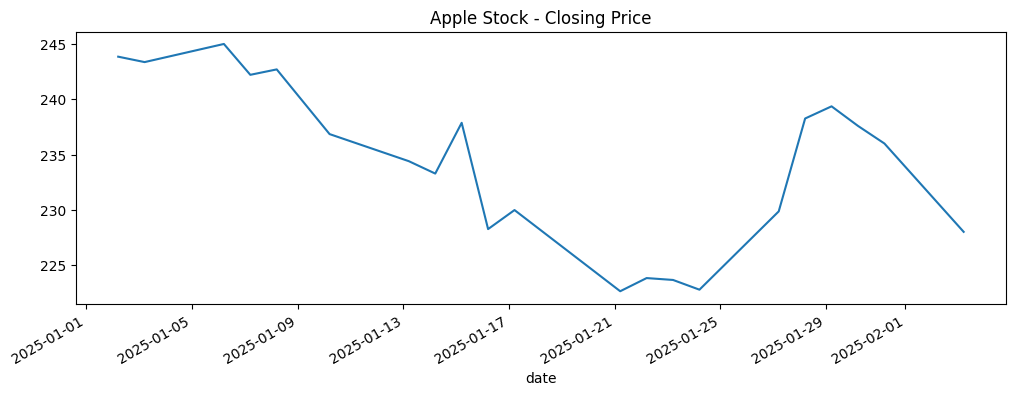

In [7]:
apple_df['close'].plot(figsize=(12, 4), title="Apple Stock - Closing Price")
plt.show()